# EEGNet Data Pipeline Visualization

This notebook shows what the data looks like at each stage of the EEGNet pipeline:
1. **Raw data**: 1024 channels per timestep
2. **After PCA**: 32 projected channels per timestep  
3. **After windowing**: 32 channels x 1600 timesteps (sliding window buffer)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.decomposition import PCA

from brainstorm.loading import load_raw_data

# Load training data
train_features, train_labels = load_raw_data(Path("../data"), step="train")
print(f"Raw data shape: {train_features.shape}")
print(f"Labels shape: {train_labels.shape}")

2026-01-24 12:40:45.313 | INFO     | brainstorm.loading:load_raw_data:38 - Loading data from: ../data
2026-01-24 12:40:45.502 | INFO     | brainstorm.loading:load_raw_data:50 - Features shape: (90386, 1024)
2026-01-24 12:40:45.502 | INFO     | brainstorm.loading:load_raw_data:51 - Labels shape: (90386, 1)
2026-01-24 12:40:45.503 | INFO     | brainstorm.loading:load_raw_data:54 - Features time range: 0.0 to 90.385
2026-01-24 12:40:45.503 | INFO     | brainstorm.loading:load_raw_data:57 - Labels time range: 0.0 to 90.385


Raw data shape: (90386, 1024)
Labels shape: (90386, 1)


## Stage 1: Raw Data (1024 channels)

Each row is one timestep (1ms). Each column is one of 1024 ECoG electrode channels.

In [2]:
# Get raw data as numpy array
X_raw = train_features.values
y = train_labels["label"].values

print(f"Raw X shape: {X_raw.shape}")
print(f"  - {X_raw.shape[0]} timesteps (samples)")
print(f"  - {X_raw.shape[1]} channels (electrodes)")
print(f"\nSingle timestep input to model (if no preprocessing):")
print(f"  Shape: (1, {X_raw.shape[1]}) = (1, 1024)")

Raw X shape: (90386, 1024)
  - 90386 timesteps (samples)
  - 1024 channels (electrodes)

Single timestep input to model (if no preprocessing):
  Shape: (1, 1024) = (1, 1024)


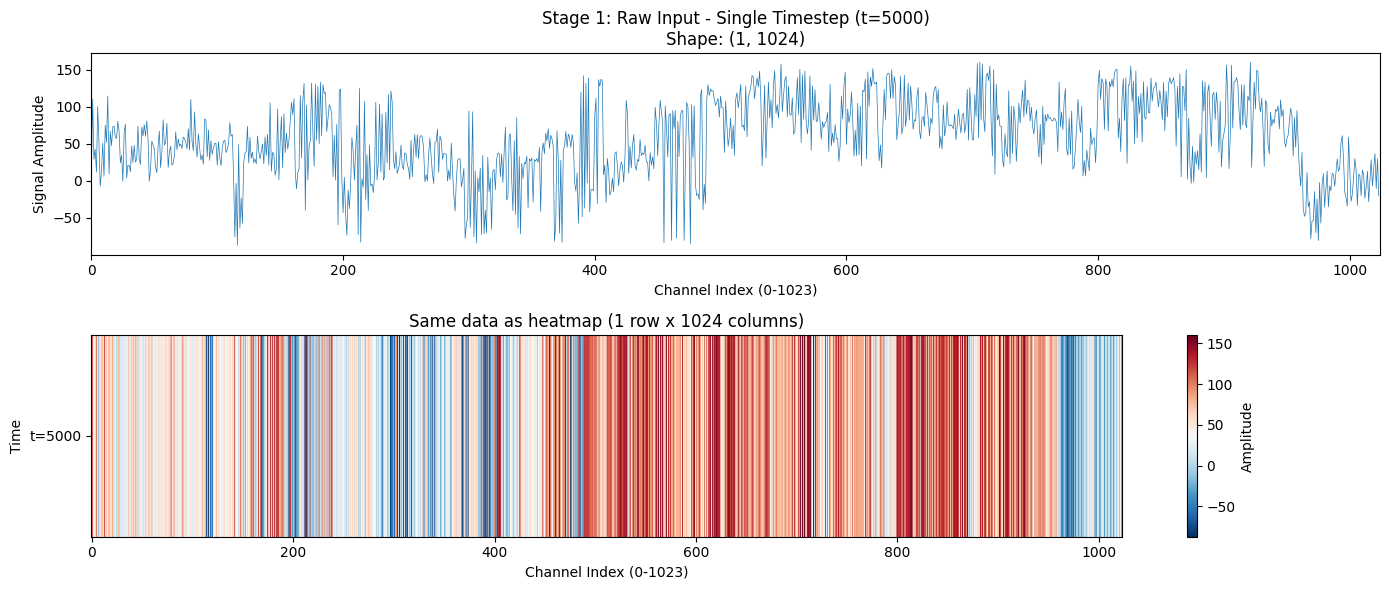


Actual values (first 10 channels): [ 15.502501  110.61375    29.20125    42.802498   11.895     100.3275
  50.7975     -7.1662498  12.09       50.84625  ]


In [3]:
# Visualize a single timestep (what the model would see as input)
timestep_idx = 5000  # Pick a sample timestep

fig, axes = plt.subplots(2, 1, figsize=(14, 6))

# Plot single timestep as bar/line
axes[0].plot(X_raw[timestep_idx], linewidth=0.5)
axes[0].set_xlabel("Channel Index (0-1023)")
axes[0].set_ylabel("Signal Amplitude")
axes[0].set_title(f"Stage 1: Raw Input - Single Timestep (t={timestep_idx})\nShape: (1, 1024)")
axes[0].set_xlim(0, 1024)

# Plot as heatmap (single row)
im = axes[1].imshow(X_raw[timestep_idx:timestep_idx+1], aspect='auto', cmap='RdBu_r')
axes[1].set_xlabel("Channel Index (0-1023)")
axes[1].set_ylabel("Time")
axes[1].set_title("Same data as heatmap (1 row x 1024 columns)")
axes[1].set_yticks([0])
axes[1].set_yticklabels([f't={timestep_idx}'])
plt.colorbar(im, ax=axes[1], label='Amplitude')

plt.tight_layout()
plt.show()

print(f"\nActual values (first 10 channels): {X_raw[timestep_idx, :10]}")

## Stage 2: After PCA (32 projected channels)

PCA reduces 1024 channels → 32 principal components. This captures the main patterns while reducing dimensionality.

In [4]:
# Fit PCA on training data (same as EEGNet does)
n_components = 32
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_raw)

print(f"After PCA shape: {X_pca.shape}")
print(f"  - {X_pca.shape[0]} timesteps (unchanged)")
print(f"  - {X_pca.shape[1]} projected channels (reduced from 1024)")
print(f"\nSingle timestep input to model (after PCA):")
print(f"  Shape: (1, {X_pca.shape[1]}) = (1, 32)")
print(f"\nVariance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%")

After PCA shape: (90386, 32)
  - 90386 timesteps (unchanged)
  - 32 projected channels (reduced from 1024)

Single timestep input to model (after PCA):
  Shape: (1, 32) = (1, 32)

Variance explained: 99.2%


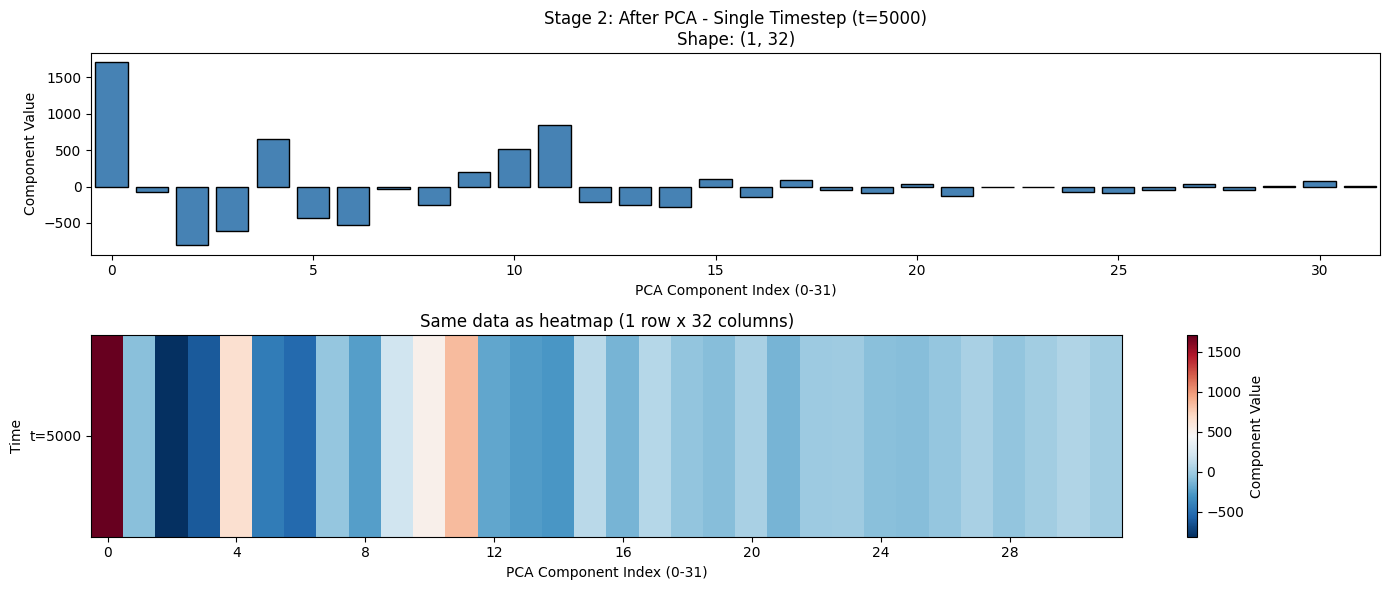


Actual values (all 32 components): 
[1707.3241     -77.0448    -809.0332    -606.9273     651.554
 -430.44586   -533.4818     -39.271416  -248.50891    198.01514
  509.65906    847.9374    -205.95345   -253.7788    -278.6427
  106.214165  -140.42531     89.33289    -45.050316   -91.19328
   39.409924  -134.30453    -12.499666    -2.3735323  -75.94708
  -87.82908    -41.852425    38.95915    -48.199776    13.257334
   75.16052     13.189997 ]


In [5]:
# Visualize single timestep after PCA
fig, axes = plt.subplots(2, 1, figsize=(14, 6))

# Plot single timestep as bar
axes[0].bar(range(n_components), X_pca[timestep_idx], color='steelblue', edgecolor='black')
axes[0].set_xlabel("PCA Component Index (0-31)")
axes[0].set_ylabel("Component Value")
axes[0].set_title(f"Stage 2: After PCA - Single Timestep (t={timestep_idx})\nShape: (1, 32)")
axes[0].set_xlim(-0.5, 31.5)

# Plot as heatmap (single row)
im = axes[1].imshow(X_pca[timestep_idx:timestep_idx+1], aspect='auto', cmap='RdBu_r')
axes[1].set_xlabel("PCA Component Index (0-31)")
axes[1].set_ylabel("Time")
axes[1].set_title("Same data as heatmap (1 row x 32 columns)")
axes[1].set_yticks([0])
axes[1].set_yticklabels([f't={timestep_idx}'])
axes[1].set_xticks(range(0, 32, 4))
plt.colorbar(im, ax=axes[1], label='Component Value')

plt.tight_layout()
plt.show()

print(f"\nActual values (all 32 components): ")
print(X_pca[timestep_idx])

## Stage 3: After Windowing (32 channels x 1600 timesteps)

The sliding window stacks the last 1600 timesteps together. This gives the model temporal context - it can see patterns across 1.6 seconds of history.

**This is what EEGNet actually sees as input for each prediction.**

In [6]:
# Create windowed data (same as EEGNet does)
window_size = 1600

def create_window(X_pca, center_idx, window_size):
    """
    Create a window of data ending at center_idx.
    Returns shape: (window_size, n_components) = (1600, 32)
    """
    start_idx = max(0, center_idx - window_size + 1)
    window = X_pca[start_idx:center_idx + 1]
    
    # Pad with zeros if we don't have enough history
    if len(window) < window_size:
        padding = np.zeros((window_size - len(window), X_pca.shape[1]))
        window = np.vstack([padding, window])
    
    return window

# Create window for our example timestep
window = create_window(X_pca, timestep_idx, window_size)

print(f"Windowed input shape: {window.shape}")
print(f"  - {window.shape[0]} timesteps in the window (1.6 seconds of history)")
print(f"  - {window.shape[1]} PCA channels")
print(f"\nThis is what EEGNet sees as input for predicting label at t={timestep_idx}")
print(f"The window contains data from t={timestep_idx-window_size+1} to t={timestep_idx}")

Windowed input shape: (1600, 32)
  - 1600 timesteps in the window (1.6 seconds of history)
  - 32 PCA channels

This is what EEGNet sees as input for predicting label at t=5000
The window contains data from t=3401 to t=5000


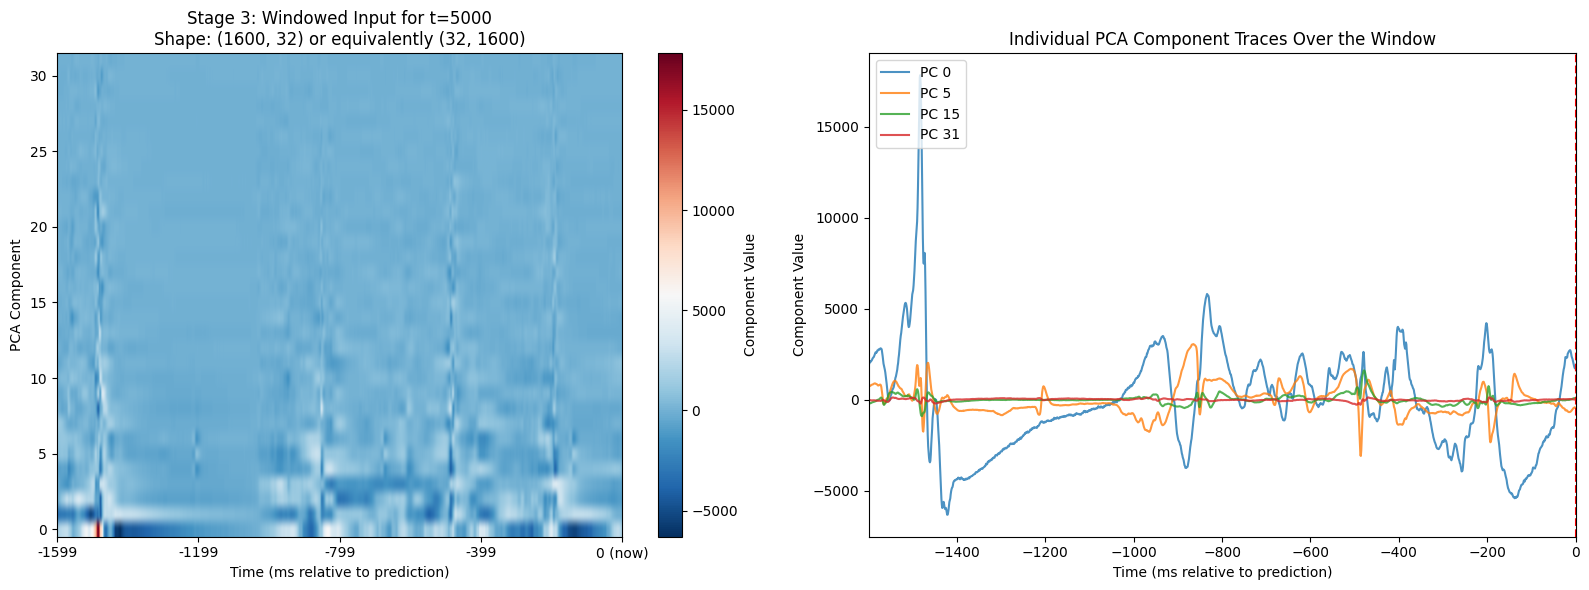

In [7]:
# Visualize the windowed input
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap of the full window
im1 = axes[0].imshow(window.T, aspect='auto', cmap='RdBu_r', origin='lower')
axes[0].set_xlabel("Time (ms relative to prediction)")
axes[0].set_ylabel("PCA Component")
axes[0].set_title(f"Stage 3: Windowed Input for t={timestep_idx}\nShape: (1600, 32) or equivalently (32, 1600)")

# Add time labels
time_ticks = [0, 400, 800, 1200, 1599]
time_labels = [f"-{window_size-1-t}" for t in time_ticks]
time_labels[-1] = "0 (now)"
axes[0].set_xticks(time_ticks)
axes[0].set_xticklabels(time_labels)
plt.colorbar(im1, ax=axes[0], label='Component Value')

# Show a few individual channel traces
channels_to_show = [0, 5, 15, 31]
time_axis = np.arange(-window_size+1, 1)  # -1599 to 0
for ch in channels_to_show:
    axes[1].plot(time_axis, window[:, ch], label=f'PC {ch}', alpha=0.8)

axes[1].set_xlabel("Time (ms relative to prediction)")
axes[1].set_ylabel("Component Value")
axes[1].set_title("Individual PCA Component Traces Over the Window")
axes[1].legend(loc='upper left')
axes[1].axvline(x=0, color='red', linestyle='--', label='Prediction time')
axes[1].set_xlim(-window_size+1, 0)

plt.tight_layout()
plt.show()

In [8]:
# Show the actual tensor shape as it goes into the neural network
# EEGNet expects: (batch, 1, channels, time) for Conv2D

# For a single sample:
model_input = window.T  # Transpose to (channels, time) = (32, 1600)
model_input = model_input[np.newaxis, np.newaxis, :, :]  # Add batch and channel dims

print("="*60)
print("SUMMARY: Data shapes at each stage")
print("="*60)
print(f"\n1. Raw data (single timestep):")
print(f"   Shape: (1024,)")
print(f"   Meaning: 1024 electrode readings at one moment")

print(f"\n2. After PCA (single timestep):")
print(f"   Shape: (32,)")
print(f"   Meaning: 32 principal components at one moment")

print(f"\n3. After windowing (what model actually sees):")
print(f"   Shape: (1600, 32) or (32, 1600)")
print(f"   Meaning: 32 PCA components x 1600 timesteps (1.6 sec history)")

print(f"\n4. As PyTorch tensor input to EEGNet:")
print(f"   Shape: {model_input.shape}")
print(f"   Meaning: (batch=1, conv_channels=1, pca_channels=32, time=1600)")

SUMMARY: Data shapes at each stage

1. Raw data (single timestep):
   Shape: (1024,)
   Meaning: 1024 electrode readings at one moment

2. After PCA (single timestep):
   Shape: (32,)
   Meaning: 32 principal components at one moment

3. After windowing (what model actually sees):
   Shape: (1600, 32) or (32, 1600)
   Meaning: 32 PCA components x 1600 timesteps (1.6 sec history)

4. As PyTorch tensor input to EEGNet:
   Shape: (1, 1, 32, 1600)
   Meaning: (batch=1, conv_channels=1, pca_channels=32, time=1600)


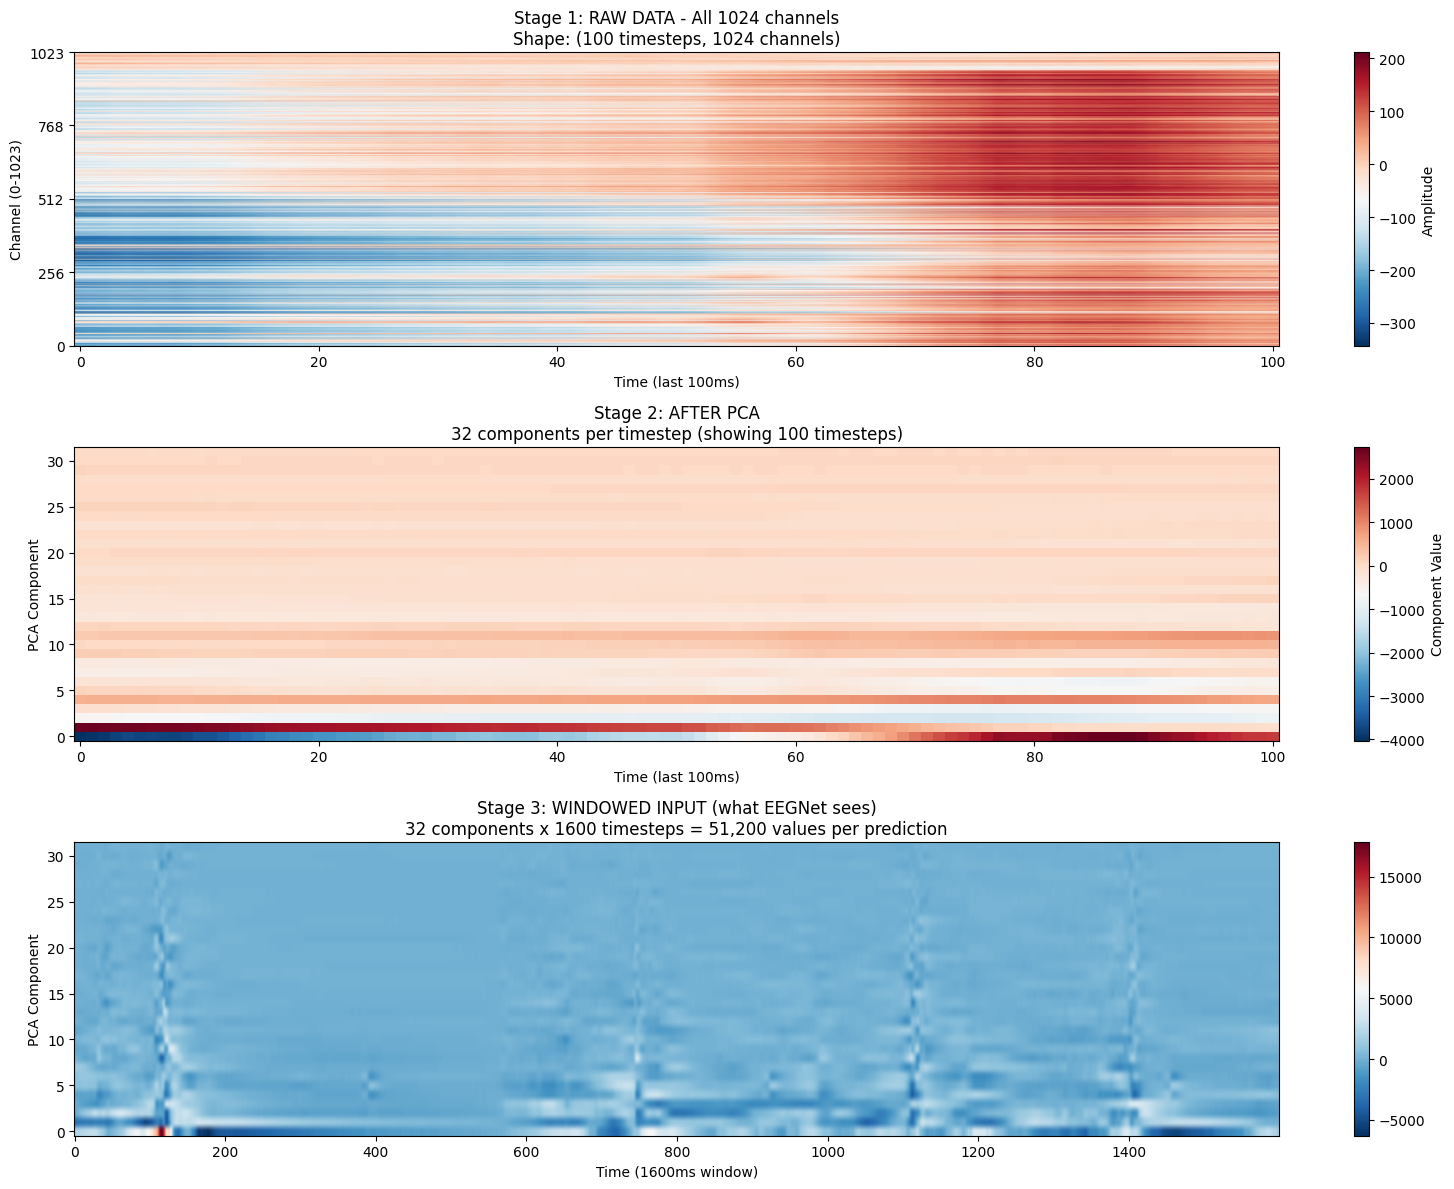


Label at t=5000: 0.0


In [9]:
# Final visualization: Compare all three stages side by side
fig = plt.figure(figsize=(16, 12))

# Stage 1: Raw - show ALL 1024 channels
ax1 = fig.add_subplot(3, 1, 1)
raw_window = X_raw[timestep_idx-100:timestep_idx+1, :]  # 100 timesteps, ALL 1024 channels
im1 = ax1.imshow(raw_window.T, aspect='auto', cmap='RdBu_r', origin='lower')
ax1.set_xlabel("Time (last 100ms)")
ax1.set_ylabel("Channel (0-1023)")
ax1.set_title(f"Stage 1: RAW DATA - All 1024 channels\nShape: (100 timesteps, 1024 channels)")
ax1.set_yticks([0, 256, 512, 768, 1023])
plt.colorbar(im1, ax=ax1, label='Amplitude')

# Stage 2: After PCA (show small window)
ax2 = fig.add_subplot(3, 1, 2)
pca_window = X_pca[timestep_idx-100:timestep_idx+1, :]  # 100 timesteps, 32 PCA
im2 = ax2.imshow(pca_window.T, aspect='auto', cmap='RdBu_r', origin='lower')
ax2.set_xlabel("Time (last 100ms)")
ax2.set_ylabel("PCA Component")
ax2.set_title("Stage 2: AFTER PCA\n32 components per timestep (showing 100 timesteps)")
plt.colorbar(im2, ax=ax2, label='Component Value')

# Stage 3: Full window (model input)
ax3 = fig.add_subplot(3, 1, 3)
im3 = ax3.imshow(window.T, aspect='auto', cmap='RdBu_r', origin='lower')
ax3.set_xlabel("Time (1600ms window)")
ax3.set_ylabel("PCA Component")
ax3.set_title(f"Stage 3: WINDOWED INPUT (what EEGNet sees)\n32 components x 1600 timesteps = 51,200 values per prediction")
plt.colorbar(im3, ax=ax3)

plt.tight_layout()
plt.show()

print(f"\nLabel at t={timestep_idx}: {y[timestep_idx]}")

## Why the Window Helps

The 1600ms window (1.6 seconds) allows the model to see:
- **Slow brain rhythms**: Alpha (8-12 Hz), Theta (4-8 Hz) waves that span hundreds of milliseconds
- **Temporal patterns**: How the signal evolves over time leading up to each prediction
- **Context**: Previous brain states that might predict current activity

Without the window, the model would only see a single 32-dimensional snapshot and miss all temporal structure.